# FNO implementation
1980 -2026 \
inputs: SSH, u_curr, v_curr, SLP, u_wind, v_wind, bathy \
outputs: SSH_(t+Δt), u_curr_(t+Δt), v_curr_(t+Δt)

## Import necessary lib

In [3]:
import torch
import torch.nn as nn
import torch.fft
import matplotlib.pyplot as plt
import numpy as np
import os
from neuralop.models import FNO
import xarray as xr

In [6]:
forcings = {}
for year in range(1980, 1982):
    data_forcing_jan = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m01.nc')
    data_forcing_feb = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m02.nc')
    data_forcing_mar = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m03.nc')
    data_forcing_apr = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m04.nc')
    data_forcing_may = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m05.nc')
    data_forcing_jun = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m06.nc')
    data_forcing_jul = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m07.nc')
    data_forcing_aug = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m08.nc')
    data_forcing_sep = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m09.nc')
    data_forcing_oct = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m10.nc')
    data_forcing_nov = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m11.nc')
    data_forcing_dec = xr.open_dataset(f'data\\forcing\\fno_ERA5forcing_y{year}m12.nc')
    forcings[year] = (data_forcing_jan, data_forcing_feb, data_forcing_mar, data_forcing_apr, data_forcing_may, data_forcing_jun, data_forcing_jul, data_forcing_aug, data_forcing_sep, data_forcing_oct, data_forcing_nov, data_forcing_dec)



msl_jan_1980 = data_forcing_jan["msl"]
u10_jan_1980 = data_forcing_jan["u10"]
v10_jan_1980 = data_forcing_jan["v10"]
msl_feb_1980 = data_forcing_feb["msl"]
u10_feb_1980 = data_forcing_feb["u10"]
v10_feb_1980 = data_forcing_feb["v10"]
msl_mar_1980 = data_forcing_mar["msl"]
u10_mar_1980 = data_forcing_mar["u10"]
v10_mar_1980 = data_forcing_mar["v10"]
msl_apr_1980 = data_forcing_apr["msl"]
u10_apr_1980 = data_forcing_apr["u10"]
v10_apr_1980 = data_forcing_apr["v10"]
msl_may_1980 = data_forcing_may["msl"]
u10_may_1980 = data_forcing_may["u10"]
v10_may_1980 = data_forcing_may["v10"]
msl_jun_1980 = data_forcing_jun["msl"]
u10_jun_1980 = data_forcing_jun["u10"]
v10_jun_1980 = data_forcing_jun["v10"]
msl_jul_1980 = data_forcing_jul["msl"]
u10_jul_1980 = data_forcing_jul["u10"]
v10_jul_1980 = data_forcing_jul["v10"]
msl_aug_1980 = data_forcing_aug["msl"]
u10_aug_1980 = data_forcing_aug["u10"]
v10_aug_1980 = data_forcing_aug["v10"]

data_forcing_feb_1983 = xr.open_dataset('data\\forcing\\fno_ERA5forcing_y1983m01.nc')

data_ssh = xr.open_dataset('data\\NAA10KM_1h_19800101_19801231_ssh.nc') # Sea surface height
data_ubar = xr.open_dataset('data\\NAA10KM_1h_19800101_19801231_ubar.nc') # U
data_vbar = xr.open_dataset('data\\NAA10KM_1h_19800101_19801231_vbar.nc') # V
data_bath = xr.open_dataset('data\\nordic_seas_domain_cfg.nc')

forcings[1980][0]


<xarray.Dataset> Size: 1GB
Dimensions:  (time: 248, lat: 241, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 2kB 1980-01-01 ... 1980-01-31T21:00:00
  * lat      (lat) float32 964B 90.0 89.75 89.5 89.25 ... 30.75 30.5 30.25 30.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    msl      (time, lat, lon) float32 344MB ...
    u10      (time, lat, lon) float32 344MB ...
    v10      (time, lat, lon) float32 344MB ...
Attributes:
    CDI:                        Climate Data Interface version ?? (http://mpi...
    Conventions:                CF-1.6
    CDO:                        Climate Data Operators version 1.9.3 (http://...
    institution:                ECMWF
    NCO:                        netCDF Operators version 5.1.9 (Homepage = ht...
    history:                    Wed Jan 21 10:07:09 2026: ncks -A -v v10 ERA5...
    history_of_appended_files:  Wed Jan 21 10:07:09 2026: Appended file ERA5f...

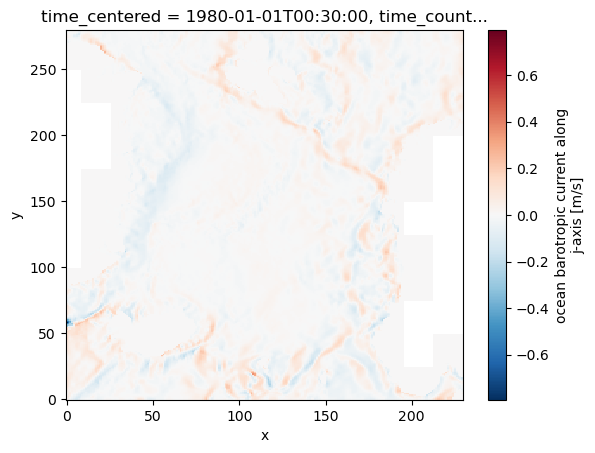

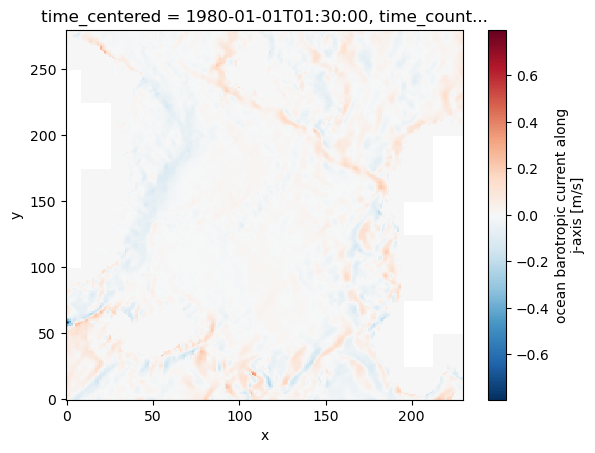

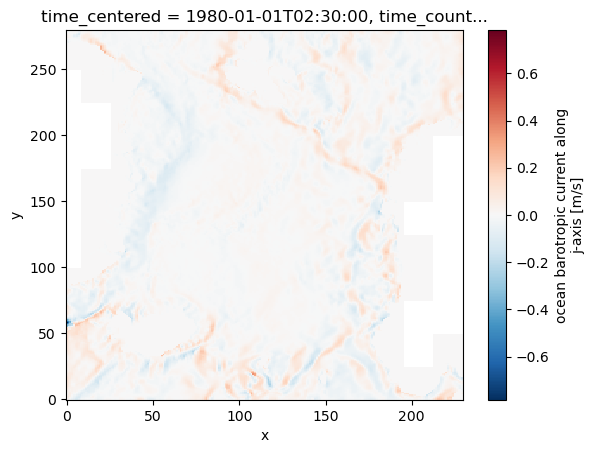

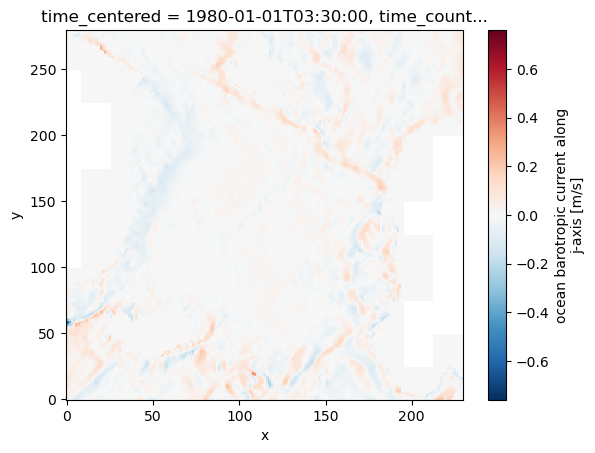

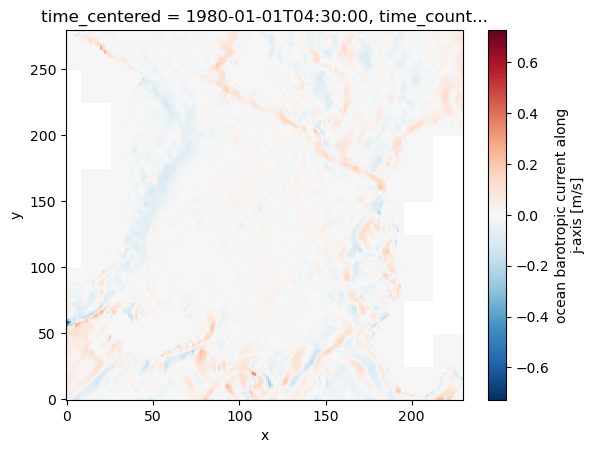

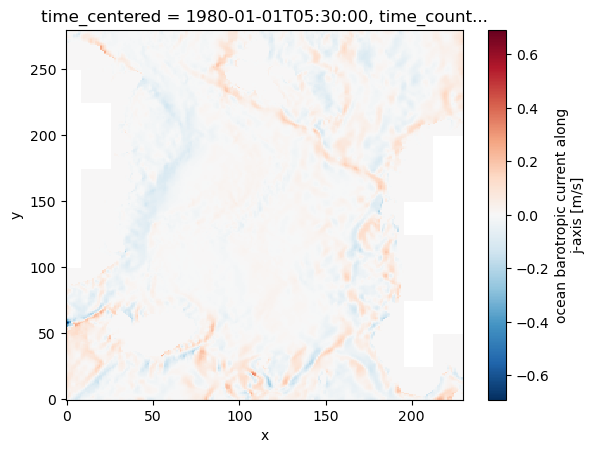

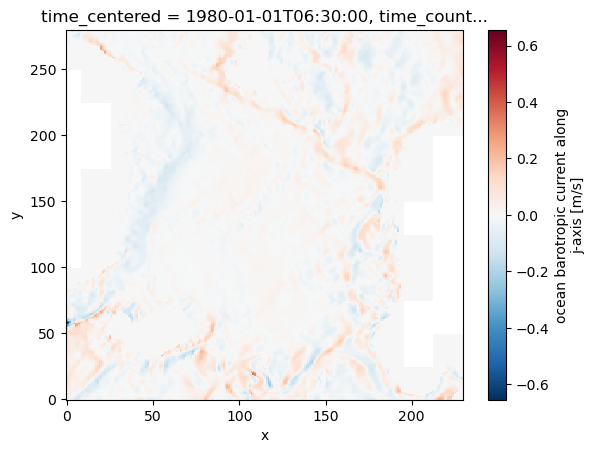

In [5]:
for i in range(0, 7):
    data_vbar["vbar"].isel(time_counter=i).plot()
    plt.show()

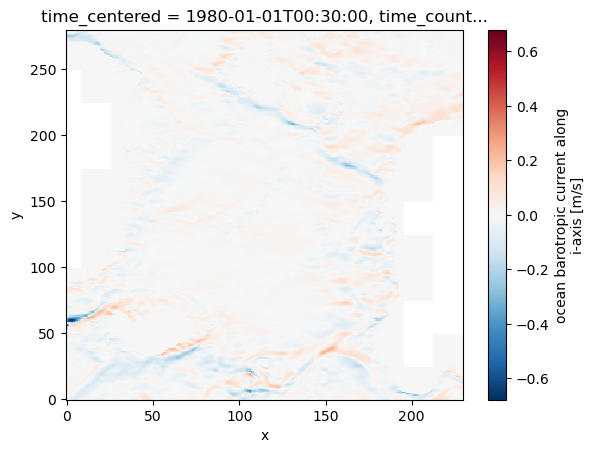

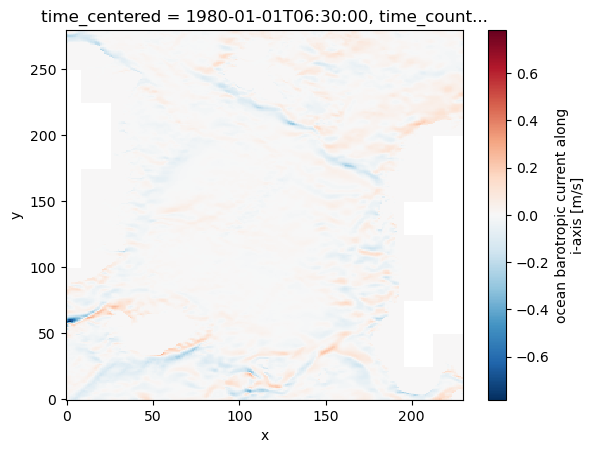

In [7]:
for i in range(0, 7, 6):
    data_ubar["ubar"].isel(time_counter=i).plot()
    plt.show()

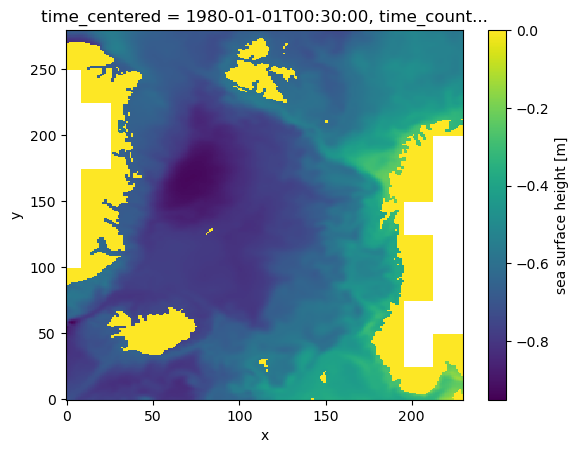

In [8]:
data_ssh["ssh"].isel(time_counter=0).plot()
plt.show()

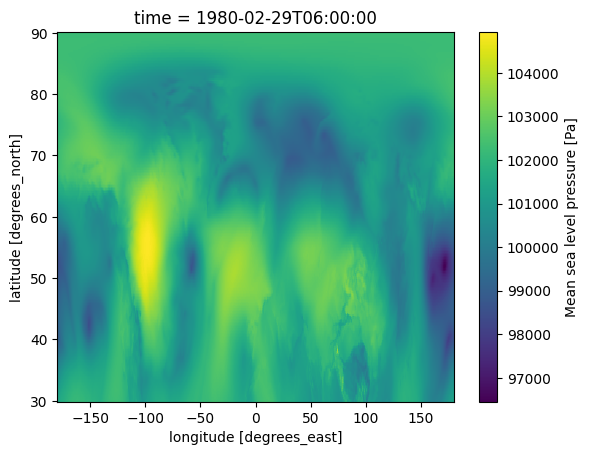

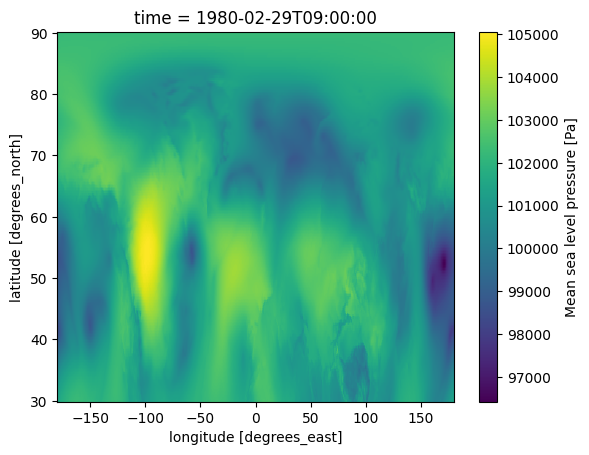

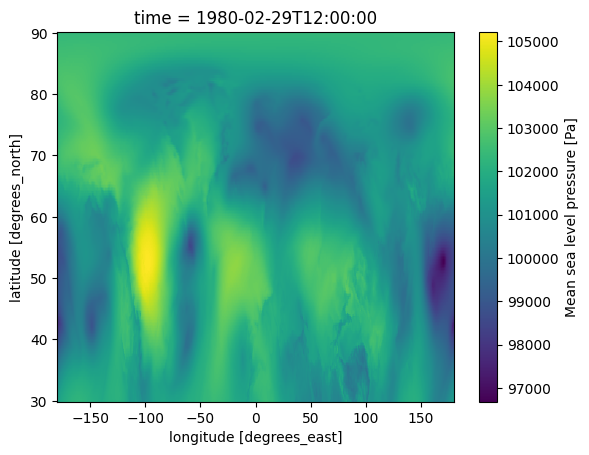

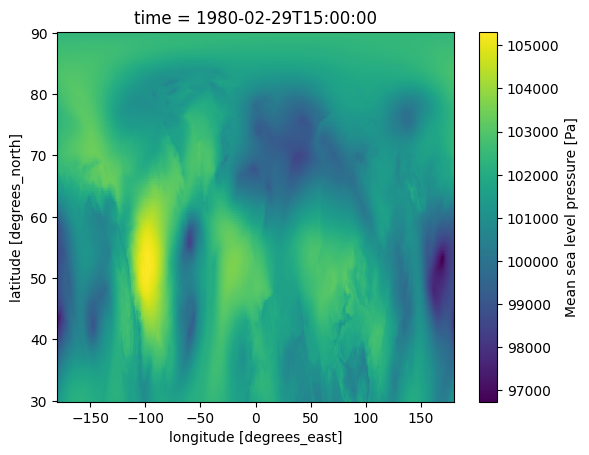

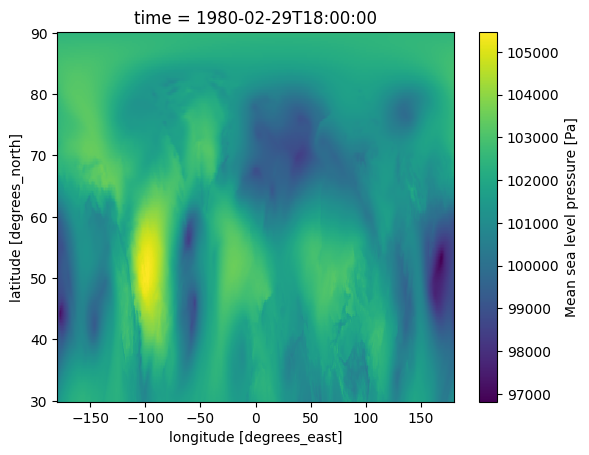

In [6]:
for i in range(-6, -1):
    data_forcing_feb["msl"].isel(time=i).plot()
    plt.show()

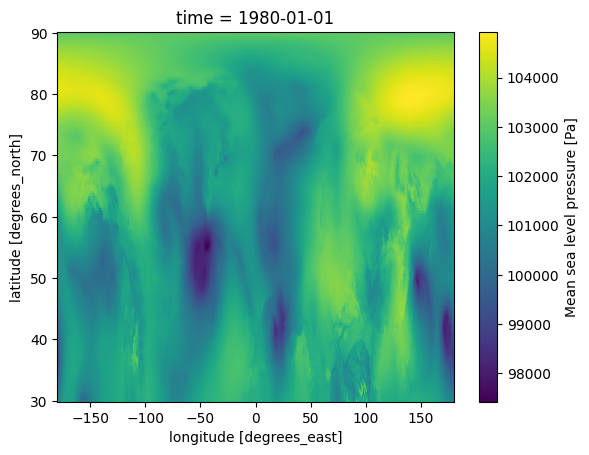

In [8]:
data_forcing_jan["msl"].isel(time=0).plot()
plt.show()

In [9]:
"""data_forcing_jan["v10"].isel(time=0).plot()
plt.show()"""

'data_forcing_jan["v10"].isel(time=0).plot()\nplt.show()'

In [10]:
target = data_forcing_feb["msl"]
print(target.lat, target.lon)

<xarray.DataArray 'lat' (lat: 241)> Size: 964B
array([90.  , 89.75, 89.5 , ..., 30.5 , 30.25, 30.  ],
      shape=(241,), dtype=float32)
Coordinates:
  * lat      (lat) float32 964B 90.0 89.75 89.5 89.25 ... 30.75 30.5 30.25 30.0
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y <xarray.DataArray 'lon' (lon: 1440)> Size: 6kB
array([-180.  , -179.75, -179.5 , ...,  179.25,  179.5 ,  179.75],
      shape=(1440,), dtype=float32)
Coordinates:
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X


In [11]:
target = data_ssh
print(target["y"], target["x"])

<xarray.DataArray 'y' (y: 280)> Size: 2kB
[280 values with dtype=int64]
Dimensions without coordinates: y <xarray.DataArray 'x' (x: 230)> Size: 2kB
[230 values with dtype=int64]
Dimensions without coordinates: x


objective: emulating barotropic ocean currents (u, v) and sea surface height (ssh) of the next time step.
inputs: U10, v10, msl, bathymetry, and previous state of the ocean (u, v, ssh)

## Make sure they have the same coordinates
## Interpolate forcing to ocean grid

In [12]:
# Check coordinate names
print("data_forcing_jan coordinates:", list(data_forcing_jan.coords.keys()))
print("data_forcing_jan dimensions:", list(data_forcing_jan.dims.keys()))
print("\ndata_ssh coordinates:", list(data_ssh.coords.keys()))
print("data_ssh dimensions:", list(data_ssh.dims.keys()))

data_forcing_jan coordinates: ['lat', 'lon', 'time']
data_forcing_jan dimensions: ['time', 'lat', 'lon']

data_ssh coordinates: ['nav_lat', 'nav_lon', 'time_centered', 'time_counter']
data_ssh dimensions: ['time_counter', 'axis_nbounds', 'y', 'x']


C:\Users\esthe\AppData\Local\Temp\ipykernel_20400\741317389.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("data_forcing_jan dimensions:", list(data_forcing_jan.dims.keys()))
C:\Users\esthe\AppData\Local\Temp\ipykernel_20400\741317389.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("data_ssh dimensions:", list(data_ssh.dims.keys()))


In [13]:
forcing_interp_jan = data_forcing_jan.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)
forcing_interp_feb = data_forcing_feb.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)
forcing_interp_mar = data_forcing_mar.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)
forcing_interp_apr = data_forcing_apr.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)
forcing_interp_may = data_forcing_may.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)
forcing_interp_jun = data_forcing_jun.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)
forcing_interp_jul = data_forcing_jul.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)
forcing_interp_aug = data_forcing_aug.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)
forcing_interp_sep = data_forcing_sep.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)
forcing_interp_oct = data_forcing_oct.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)
forcing_interp_nov = data_forcing_nov.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)

forcing_interp_dec = data_forcing_dec.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)

In [14]:
# Check actual shapes
print("data_forcing_jan['u10'].shape:", data_forcing_jan['u10'].shape)
print("data_forcing_jan['v10'].shape:", data_forcing_jan['v10'].shape)
print("data_forcing_jan['msl'].shape:", data_forcing_jan['msl'].shape)
print()
print("forcing_interp['u10'].shape:", forcing_interp_dec['u10'].shape)
print("forcing_interp['v10'].shape:", forcing_interp_dec['v10'].shape)
print("forcing_interp['msl'].shape:", forcing_interp_dec['msl'].shape)
print()
print("data_ssh['ssh'].shape:", data_ssh['ssh'].shape)
print("data_ssh['ssh'] variables:", data_ssh['ssh'].dims)
print()
print("data_ubar['ubar'].shape:", data_ubar['ubar'].shape)
print("data_ubar['ubar'] variables:", data_ubar['ubar'].dims)
print()
print("data_vbar['vbar'].shape:", data_vbar['vbar'].shape)
print("data_vbar['vbar'] variables:", data_vbar['vbar'].dims)

data_forcing_jan['u10'].shape: (248, 241, 1440)
data_forcing_jan['v10'].shape: (248, 241, 1440)
data_forcing_jan['msl'].shape: (248, 241, 1440)

forcing_interp['u10'].shape: (248, 280, 230)
forcing_interp['v10'].shape: (248, 280, 230)
forcing_interp['msl'].shape: (248, 280, 230)

data_ssh['ssh'].shape: (8784, 280, 230)
data_ssh['ssh'] variables: ('time_counter', 'y', 'x')

data_ubar['ubar'].shape: (8784, 280, 230)
data_ubar['ubar'] variables: ('time_counter', 'y', 'x')

data_vbar['vbar'].shape: (8784, 280, 230)
data_vbar['vbar'] variables: ('time_counter', 'y', 'x')


In [ ]:
# Instead of concatenating all months in memory at once (MemoryError),
# process each month sequentially and collect the arrays.
months = [data_forcing_jan, data_forcing_feb, data_forcing_mar,
          data_forcing_apr, data_forcing_may, data_forcing_jun,
          data_forcing_jul, data_forcing_aug, data_forcing_sep,
          data_forcing_oct, data_forcing_nov, data_forcing_dec]

interp_list = []
for ds in months:
    # spatial interpolation for this month
    tmp = ds.interp(lat=data_ssh.nav_lat, lon=data_ssh.nav_lon, method='linear')
    # take only necessary variables and convert to numpy
    arr = np.stack([tmp['u10'].values, tmp['v10'].values, tmp['msl'].values], axis=1)
    # arr shape: (time, 3, y, x)
    interp_list.append(arr)
    print(f"Processed month shape: {arr.shape}")

# concatenate along time axis
forcing_all_np = np.concatenate(interp_list, axis=0)
print("Concatenated forcing array shape", forcing_all_np.shape)

# if desired, you can convert back to xarray later
# forcing_interp = xr.DataArray(forcing_all_np, dims=('time','var','y','x'))

# we'll use forcing_all_np when building inputs


Processed month shape: (248, 3, 280, 230)
Processed month shape: (232, 3, 280, 230)
Processed month shape: (248, 3, 280, 230)
Processed month shape: (240, 3, 280, 230)
Processed month shape: (248, 3, 280, 230)
Processed month shape: (240, 3, 280, 230)
Processed month shape: (248, 3, 280, 230)
Processed month shape: (248, 3, 280, 230)
Processed month shape: (240, 3, 280, 230)
Processed month shape: (248, 3, 280, 230)
Processed month shape: (240, 3, 280, 230)
Processed month shape: (248, 3, 280, 230)


In [ ]:
# Now stack inputs: [time, channels, x, y]
# channels = [u10, v10, msl, ssh_t, ubar_t, vbar_t]
# forcing_all_np has shape (total_time, 3, y, x)
inputs = np.concatenate([
    forcing_all_np,
    data_ssh['ssh'].values[:, None, :, :],
    data_ubar['ubar'].values[:, None, :, :],
    data_vbar['vbar'].values[:, None, :, :],
], axis=1)  # Shape: [time, 6, x, y]

print(f"Inputs shape: {inputs.shape}")


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 2928 and the array at index 1 has size 8784

In [ ]:
# Outputs: [time, channels, x, y] 
# channels = [ssh_t+1, ubar_t+1, vbar_t+1]
outputs = np.stack([
    data_ssh['ssh'].values[1:],      # ssh at t+1
    data_ubar['ubar'].values[1:],    # ubar at t+1
    data_vbar['vbar'].values[1:],    # vbar at t+1
], axis=1)  # Shape: [time-1, 3, x, y]

# Align shapes: drop last forcing timestep
inputs = inputs[:-1]
print(f"Outputs shape: {outputs.shape}")
print(f"Aligned inputs shape: {inputs.shape}")


In [ ]:
# Convert to torch tensors
inputs_torch = torch.from_numpy(inputs).float()
outputs_torch = torch.from_numpy(outputs).float()

In [ ]:
# inspect cells for forcing_interp usage without nbformat
import json
with open(r'c:\\Users\\esthe\\Documents\\UiO\\Master thesis\\Masters-thesis-FNO-Nordic-Sea\\fno.ipynb','r',encoding='utf-8') as f:
    nb = json.load(f)
for idx, cell in enumerate(nb['cells']):
    if cell['cell_type']=='code':
        src = ''.join(cell['source']) if isinstance(cell['source'], list) else cell['source']
        if 'forcing_interp' in src:
            print('cell', idx)
            print(src)
            print('--')


cell 16
forcing_interp_jan = data_forcing_jan.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)
forcing_interp_feb = data_forcing_feb.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)
forcing_interp_mar = data_forcing_mar.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)
forcing_interp_apr = data_forcing_apr.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)
forcing_interp_may = data_forcing_may.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)
forcing_interp_jun = data_forcing_jun.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)
forcing_interp_jul = data_forcing_jul.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)
forcing_interp_aug = data_forcing_aug.interp(
    lat=data_ssh.nav_lat, 
    lon=data_ssh.nav_lon, 
    method='linear'
)
forcing_interp_s

In [ ]:
import xarray as xr
from glob import glob

files = sorted(glob("ECMWF/fno_ERA5forcing_*.nc"))

ds = xr.open_mfdataset(
    files,
    combine="by_coords",   # important
    parallel=True
)

print(ds)

OSError: no files to open